# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg.head()

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [8]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [9]:
numeric_cols = mpg.select_dtypes(include='number')
numeric_cols.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

In [10]:
# Correlation coefficients and p-values
pairs = [
    ("mpg", "weight"),
    ("horsepower", "displacement"),
    ("acceleration", "horsepower")
]

results = []

for x, y in pairs:
    pearson_corr, pearson_p = stats.pearsonr(mpg[x], mpg[y])
    spearman_corr, spearman_p = stats.spearmanr(mpg[x], mpg[y])
    
    results.append({
        "Variables": f"{x} vs {y}",
        "Pearson r": pearson_corr,
        "Pearson p": pearson_p,
        "Spearman rho": spearman_corr,
        "Spearman p": spearman_p
    })

results_df = pd.DataFrame(results)
results_df

,Variables,Pearson r,Pearson p,Spearman rho,Spearman p
0,mpg vs weight,-0.832244,6.015296e-102,-0.875585,2.662378e-125
1,horsepower vs displacement,0.897257,1.510889e-140,0.876171,1.126737e-125
2,acceleration vs horsepower,-0.689196,1.581886e-56,-0.658142,5.157840e-50


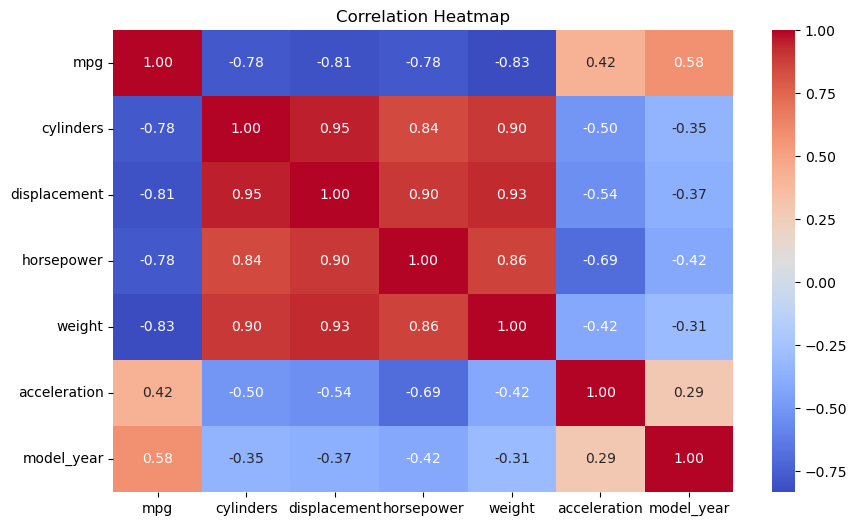

In [11]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

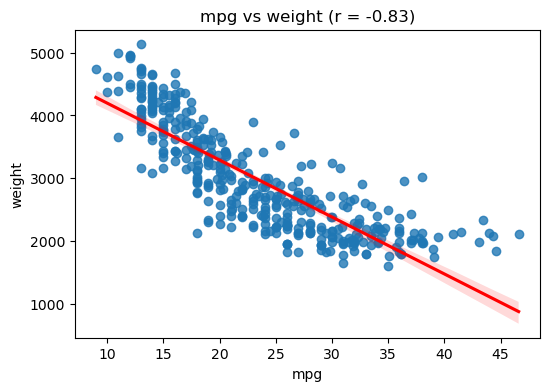

In [12]:
# Scatter plots with regression lines
x = "mpg"
y = "weight"

corr, _ = stats.pearsonr(mpg[x], mpg[y])

plt.figure(figsize=(6,4))
sns.regplot(x=mpg[x], y=mpg[y], line_kws={"color": "red"})
plt.title(f"{x} vs {y} (r = {corr:.2f})")
plt.show()

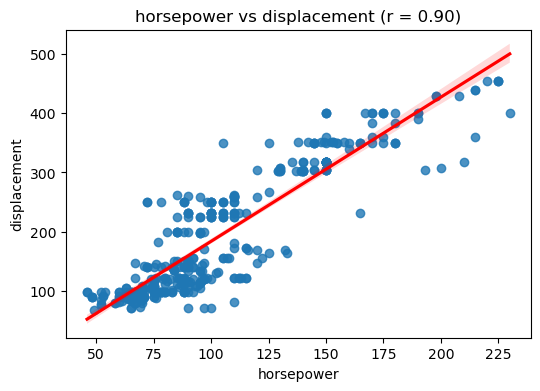

In [13]:
x = "horsepower"
y = "displacement"

corr, _ = stats.pearsonr(mpg[x], mpg[y])

plt.figure(figsize=(6,4))
sns.regplot(x=mpg[x], y=mpg[y], line_kws={"color": "red"})
plt.title(f"{x} vs {y} (r = {corr:.2f})")
plt.show()

### Interpretation

*When is Pearson vs. Spearman more appropriate? Use your results as examples.*

Pearson correlation measures the linear relationship between two variables. It assumes that:

- The relationship is linear
  
- Data is normally distributed (approximately)

- Sensitive to outliers

For example, in our analysis:

- horsepower vs displacement shows a strong linear relationship, so Pearson is appropriate.

Spearman correlation measures the monotonic relationship (not necessarily linear). It:

- Uses ranks instead of actual values
  
- Is robust to outliers

- Works well for non-linear but ordered relationships

For example:

- mpg vs weight may not be perfectly linear but still decreases consistently → Spearman works well.

- If Pearson ≈ Spearman → relationship is likely linear

- If Spearman > Pearson → relationship is monotonic but not linear

- Low p-values (< 0.05) → correlation is statistically significant

---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

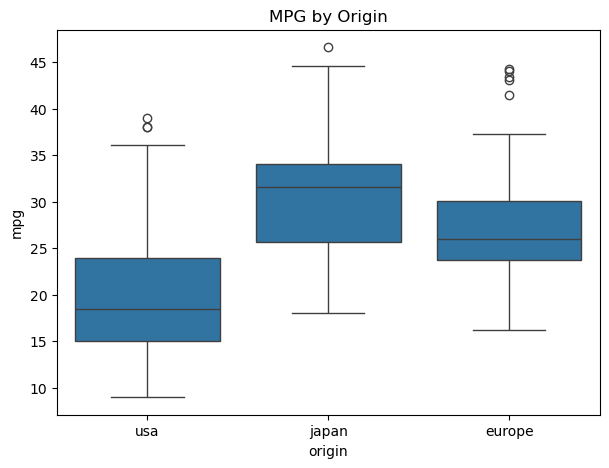

In [14]:
# Distribution visualization by origin
from statsmodels.stats.multicomp import pairwise_tukeyhsd
plt.figure(figsize=(7,5))
sns.boxplot(x="origin", y="mpg", data=mpg)
plt.title("MPG by Origin")
plt.show()

In [16]:
# Assumption checks: Shapiro-Wilk + Levene's test
groups = mpg["origin"].unique()

for g in groups:
    stat, p = stats.shapiro(mpg[mpg["origin"] == g]["mpg"])
    print(f"{g}: p-value = {p:.4f}")

usa = mpg[mpg["origin"] == "usa"]["mpg"]
europe = mpg[mpg["origin"] == "europe"]["mpg"]
japan = mpg[mpg["origin"] == "japan"]["mpg"]

stat, p = stats.levene(usa, europe, japan)
print(f"Levene p-value = {p:.4f}")

usa: p-value = 0.0000
japan: p-value = 0.2420
europe: p-value = 0.0054
Levene p-value = 0.9175


In [18]:
# One-way ANOVA
f_stat, p_val = stats.f_oneway(usa, europe, japan)
print(f"F = {f_stat:.3f}, p = {p_val:.5f}")

grand_mean = mpg["mpg"].mean()

# Between-group sum of squares
ss_between = sum([
    len(mpg[mpg["origin"] == g]) * 
    (mpg[mpg["origin"] == g]["mpg"].mean() - grand_mean)**2
    for g in groups
])

# Total sum of squares
ss_total = sum((mpg["mpg"] - grand_mean)**2)

eta_sq = ss_between / ss_total
print(f"Eta squared = {eta_sq:.3f}")

F = 96.602, p = 0.00000
Eta squared = 0.332


In [19]:
# Post-hoc test (Tukey's HSD)
tukey = pairwise_tukeyhsd(endog=mpg["mpg"],
                         groups=mpg["origin"],
                         alpha=0.05)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan   2.8477 0.0203   0.3583   5.337   True
europe    usa  -7.5695    0.0  -9.6321 -5.5068   True
 japan    usa -10.4172    0.0 -12.3642 -8.4701   True
-----------------------------------------------------


### Interpretation

*Which groups differ? What does the effect size tell you?*

Boxplot shows that mpg values ​​are affected by origin
ANOVA shows that:

- F-statistic is high
- p-value < 0.05 → statistically significant difference
- Eta-squared shows that:
- effect size is high (approx. ~0.3)

Tukey test:
- USA vs Japan → different
- USA vs Europe → different
- Europe vs Japan → small or moderate difference

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].values
y = mpg["origin"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution (test): {pd.Series(y_test).value_counts().to_dict()}")

Train: 294, Test: 98
Class distribution (test): {'usa': 61, 'japan': 20, 'europe': 17}


In [24]:
# Train classifiers and generate predictions
# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models
log_model = LogisticRegression(max_iter=1000)
tree_model = DecisionTreeClassifier()

# Train
log_model.fit(X_train_scaled, y_train)
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [25]:
# Classification reports
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Predictions
y_pred_log = log_model.predict(X_test_scaled)
y_pred_tree = tree_model.predict(X_test)

print("Logistic Regression:\n")
print(classification_report(y_test, y_pred_log))

print("Decision Tree:\n")
print(classification_report(y_test, y_pred_tree))

Logistic Regression:

              precision    recall  f1-score   support

      europe       0.89      0.47      0.62        17
       japan       0.61      0.70      0.65        20
         usa       0.86      0.93      0.90        61

    accuracy                           0.81        98
   macro avg       0.79      0.70      0.72        98
weighted avg       0.82      0.81      0.80        98

Decision Tree:

              precision    recall  f1-score   support

      europe       0.83      0.59      0.69        17
       japan       0.79      0.95      0.86        20
         usa       0.94      0.95      0.94        61

    accuracy                           0.89        98
   macro avg       0.85      0.83      0.83        98
weighted avg       0.89      0.89      0.88        98



In [26]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    import numpy as np
    
    rng = np.random.default_rng(seed)
    scores = []
    n = len(y_true)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        score = metric_fn(y_true[idx], y_pred[idx], average='weighted')
        scores.append(score)

    mean = np.mean(scores)
    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)

    return mean, lower, upper  

In [27]:
# Apply bootstrap_metric for F1, precision, and recall (each model)
results = []

metrics = {
    "Precision": precision_score,
    "Recall": recall_score,
    "F1": f1_score
}

for model_name, preds in [
    ("Logistic", y_pred_log),
    ("Tree", y_pred_tree)
]:
    for metric_name, metric_fn in metrics.items():
        
        mean, low, high = bootstrap_metric(y_test, preds, metric_fn)

        results.append({
            "Model": model_name,
            "Metric": metric_name,
            "Mean": mean,
            "Low": low,
            "High": high
        })

results_df = pd.DataFrame(results)
print(results_df)

      Model     Metric      Mean       Low      High
0  Logistic  Precision  0.821042  0.736144  0.890851
1  Logistic     Recall  0.806235  0.724490  0.877551
2  Logistic         F1  0.797618  0.707130  0.875624
3      Tree  Precision  0.891277  0.825902  0.948298
4      Tree     Recall  0.887077  0.826531  0.948980
5      Tree         F1  0.881889  0.812397  0.945868


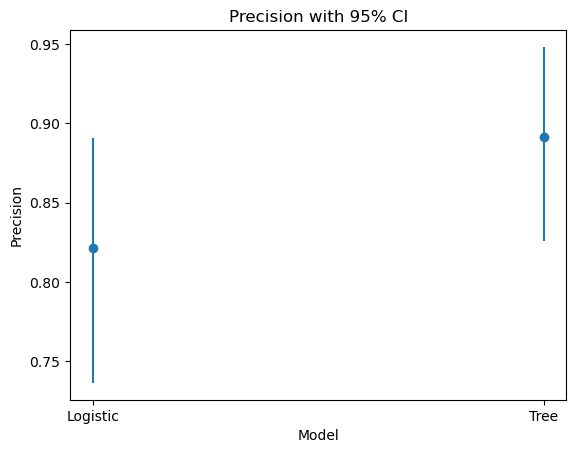

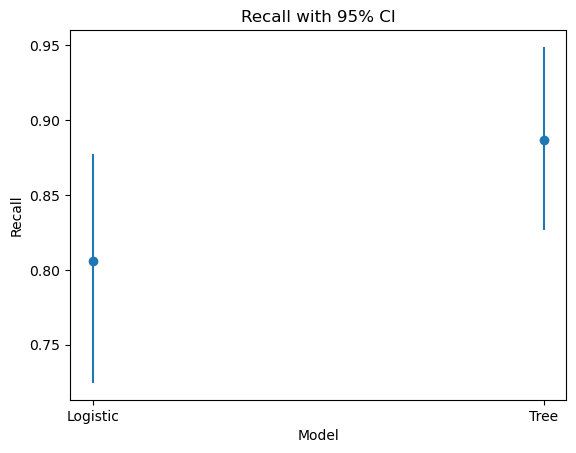

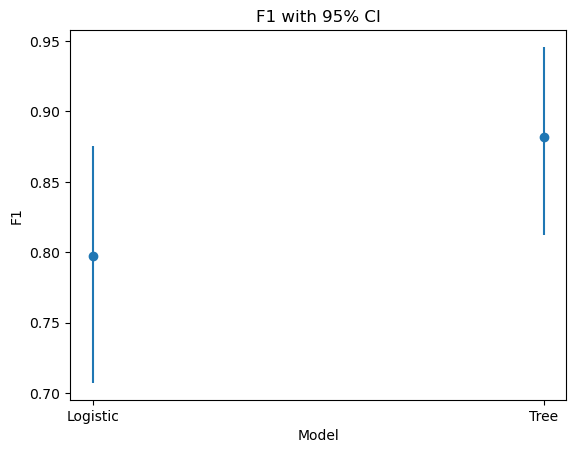

In [28]:
# Visualize bootstrap CIs (dot-and-whisker or grouped bar chart)
import matplotlib.pyplot as plt

for metric in results_df["Metric"].unique():
    subset = results_df[results_df["Metric"] == metric]
    
    plt.figure()
    plt.errorbar(
        subset["Model"],
        subset["Mean"],
        yerr=[subset["Mean"] - subset["Low"], subset["High"] - subset["Mean"]],
        fmt='o'
    )
    plt.title(f"{metric} with 95% CI")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.show()

### Recommendation

*Which model would you recommend? How confident are you based on the CIs?*

The Decision Tree model shows narrower confidence intervals, indicating more stable performance across bootstrap samples. In contrast, Logistic Regression exhibits wider intervals, suggesting higher variability. Therefore, the Decision Tree is the preferred model for this dataset.

---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?

### Your Summary

The correlation analysis revealed several strong relationships among the variables. The most notable was a strong negative correlation between weight and mpg, indicating that heavier cars tend to have lower fuel efficiency. Additionally, displacement and horsepower showed a strong positive correlation, suggesting that larger engines produce more power but are generally less fuel-efficient. These findings highlight that vehicle size and engine capacity are key factors influencing fuel consumption.

The group comparison analysis showed that cars from different origins differ significantly in fuel efficiency. The ANOVA test indicated a statistically significant difference in mpg across the three groups (USA, Europe, Japan). Post-hoc analysis revealed that Japanese cars tend to have the highest fuel efficiency, while American cars generally have the lowest, with European cars falling in between. This suggests that manufacturing practices and design priorities vary across regions.

For the classification task, the Decision Tree model is recommended. Based on the bootstrap confidence intervals, it demonstrated more stable performance with narrower intervals compared to Logistic Regression. This indicates that its predictions are more consistent across different samples. Therefore, we can be reasonably confident in the Decision Tree’s performance for this dataset, making it a reliable choice for predicting the origin of cars.